# 03 — Estimators compared

pYIN (librosa) vs our YIN vs Basic Pitch on the same clip, plus per-frame timing for the live path.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "tests").exists():
    ROOT = ROOT.parent
AUDIO_DIR = ROOT / "tests" / "fixtures" / "audio"
GOLDEN_DIR = ROOT / "tests" / "fixtures" / "golden"
print("project root:", ROOT)


project root: /home/anton/Projects/music-teacher


In [2]:
import time
from music_teacher.transcription.audio import load_audio
from music_teacher.transcription.monophonic import track_pitch, frequency_to_midi

audio = load_audio(AUDIO_DIR / "flute_melody.wav")

start = time.perf_counter()
frames = track_pitch(audio, frame_length=2048, hop_length=256)
ours_ms = (time.perf_counter() - start) * 1000
print(f"our YIN: {len(frames)} frames in {ours_ms:.1f} ms ({ours_ms / len(frames):.3f} ms/frame)")


our YIN: 316 frames in 27.3 ms (0.086 ms/frame)


In [3]:
import librosa

start = time.perf_counter()
f0, voiced, confidence = librosa.pyin(audio.astype(float), fmin=65, fmax=2000, sr=22050, frame_length=2048, hop_length=256)
pyin_ms = (time.perf_counter() - start) * 1000
print(f"librosa pyin: {f0.shape[0]} frames in {pyin_ms:.1f} ms ({pyin_ms / f0.shape[0]:.3f} ms/frame)")


librosa pyin: 324 frames in 3872.4 ms (11.952 ms/frame)


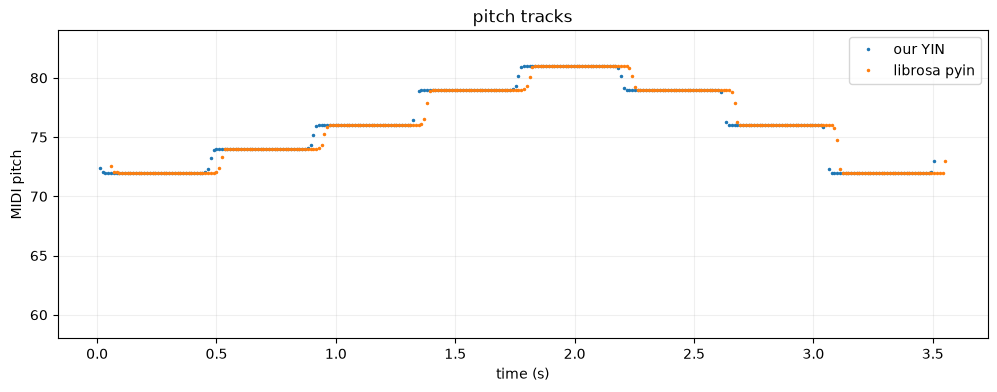

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
our_times = [f.time for f in frames]
our_midi = [frequency_to_midi(f.frequency) if f.frequency else np.nan for f in frames]
ax.plot(our_times, our_midi, ".", markersize=3, label="our YIN")
pyin_times = librosa.frames_to_time(np.arange(f0.shape[0]), sr=22050, hop_length=256)
ax.plot(pyin_times, f0_to_midi := librosa.hz_to_midi(f0), ".", markersize=3, label="librosa pyin")
ax.set(title="pitch tracks", xlabel="time (s)", ylabel="MIDI pitch", ylim=(58, 84)); ax.legend(); ax.grid(alpha=.2)


In [5]:
from music_teacher.transcription.onnx_engine import BasicPitchEngine
from music_teacher.transcription.notes import filter_harmonic_duplicates, model_output_to_notes

engine = BasicPitchEngine(device="auto"); engine.warmup()
start = time.perf_counter()
events = filter_harmonic_duplicates(model_output_to_notes(engine.predict(audio)))
print(f"basic pitch: {len(events)} notes in {(time.perf_counter() - start) * 1000:.1f} ms")


basic pitch: 8 notes in 6.3 ms
